Nombre de classes détectées : 3
Classes : ['normal', 'covid', 'virus']


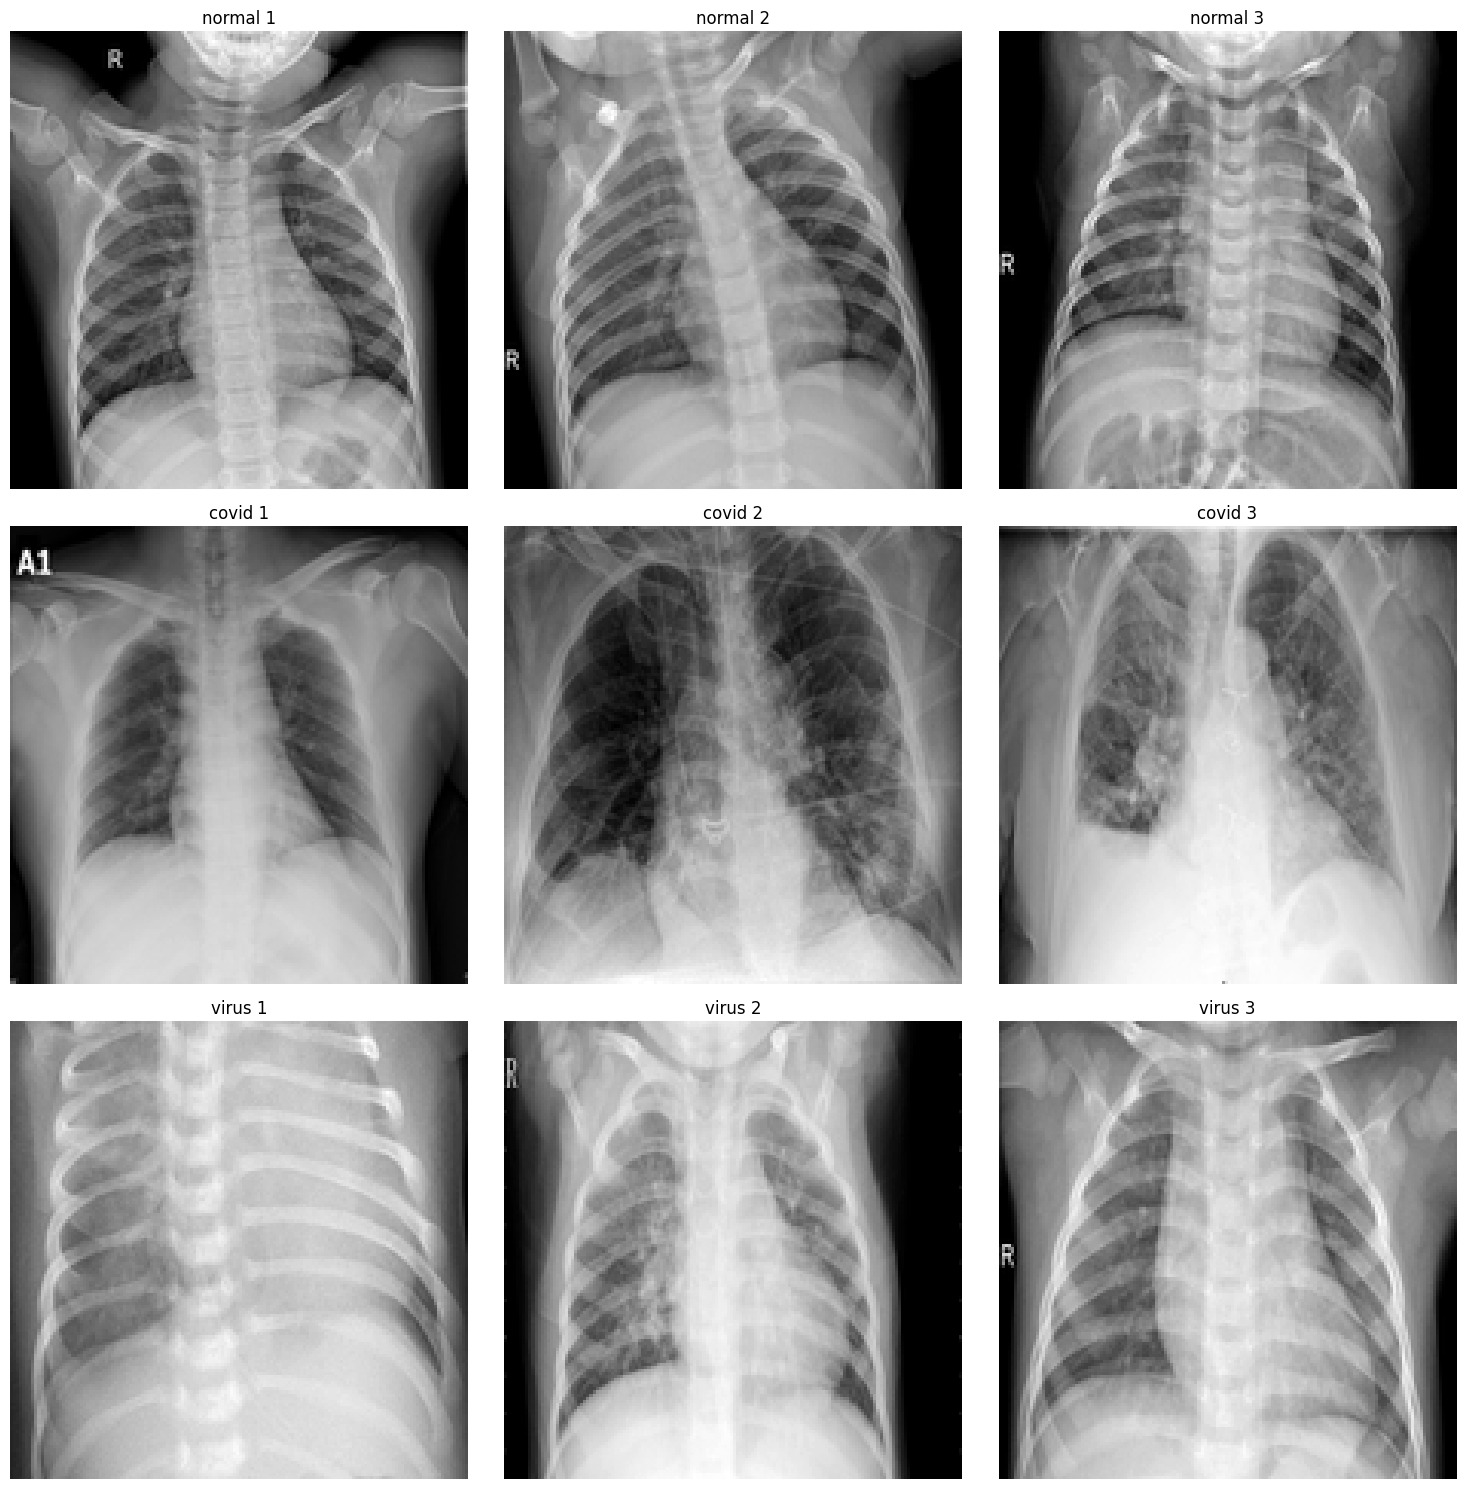

In [36]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Chemin du répertoire contenant les images
image_dir = '/kaggle/input/covid-19-chest-x-ray/Data'

# Liste des sous-dossiers représentant les classes
class_names = [d for d in os.listdir(image_dir) if os.path.isdir(os.path.join(image_dir, d))]

# Afficher le nombre de classes détectées
print(f"Nombre de classes détectées : {len(class_names)}")
print("Classes :", class_names)

# Nombre d'images à afficher par classe
images_per_class = 3

# Taille cible pour redimensionner les images
target_size = (150, 150)  # Largeur, Hauteur

# Initialiser la figure pour l'affichage
fig, axes = plt.subplots(len(class_names), images_per_class, figsize=(15, 5 * len(class_names)))

# Parcourir chaque classe
for i, class_name in enumerate(class_names):
    class_dir = os.path.join(image_dir, class_name)
    images = [os.path.join(class_dir, img) for img in os.listdir(class_dir) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    # Sélectionner un nombre d'images à afficher
    selected_images = random.sample(images, min(images_per_class, len(images)))
    
    # Afficher les images sélectionnées
    for j, img_path in enumerate(selected_images):
        # Ouvrir l'image
        with Image.open(img_path) as img:
            # Convertir l'image en niveaux de gris
            img_gray = img.convert('L')
            # Redimensionner l'image
            img_resized = img_gray.resize(target_size, Image.Resampling.LANCZOS)
            # Convertir l'image en tableau numpy pour l'affichage
            img_array = np.array(img_resized)
            # Afficher l'image
            axes[i, j].imshow(img_array, cmap='gray')
            axes[i, j].axis('off')
            axes[i, j].set_title(f"{class_name} {j + 1}")

# Ajuster l'affichage
plt.tight_layout()
plt.show()



Répartition des images :

TRAIN:
  Classe 'normal': 374 images
  Classe 'virus': 346 images
  Classe 'covid': 236 images
  Total: 956 images

VAL:
  Classe 'normal': 46 images
  Classe 'virus': 43 images
  Classe 'covid': 29 images
  Total: 118 images

TEST:
  Classe 'normal': 48 images
  Classe 'virus': 44 images
  Classe 'covid': 30 images
  Total: 122 images
Found 956 images belonging to 3 classes.
Found 118 images belonging to 3 classes.
Found 122 images belonging to 3 classes.


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.4273 - loss: 1.2095
Epoch 1: val_loss improved from inf to 0.62903, saving model to best_model.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 58s 461ms/step - accuracy: 0.4281 - loss: 1.2077 - val_accuracy: 0.7203 - val_loss: 0.6290
Epoch 2/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.6901 - loss: 0.7461
Epoch 2: val_loss improved from 0.62903 to 0.59869, saving model to best_model.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 55s 452ms/step - accuracy: 0.6900 - loss: 0.7460 - val_accuracy: 0.7627 - val_loss: 0.5987
Epoch 3/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.7399 - loss: 0.6130
Epoch 3: val_loss improved from 0.59869 to 0.41566, saving model to best_model.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 55s 454ms/step - accuracy: 0.7401 - loss: 0.6127 - val_accuracy: 0.8390 - val_loss: 0.4157
Epoch 4/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.7699 - loss: 0.5189
Epoch 4: val_loss did not improve from 0.41566
1

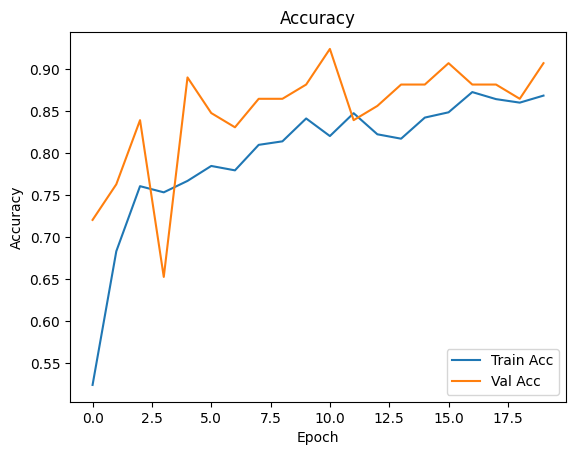

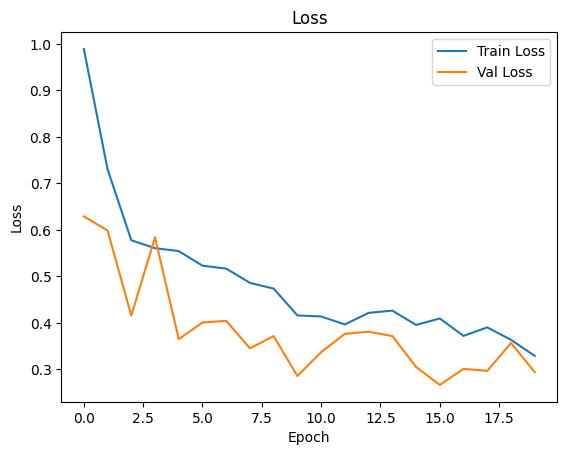

In [9]:
import os
import shutil
import random
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.utils import class_weight
from sklearn.metrics import classification_report

# Dossiers
ORIGINAL_DATASET_DIR = '/kaggle/input/covid-19-chest-x-ray/Data'
SPLIT_DATASET_DIR = '/kaggle/working/split_data'

# Paramètres
IMAGE_SIZE = 224
BATCH_SIZE = 8
CHANNELS = 1
EPOCHS = 20
SPLIT_RATIOS = (0.8, 0.1, 0.1)

# Fonction de split
def split_dataset(original_dir, split_dir, split_ratios):
    if os.path.exists(split_dir):
        shutil.rmtree(split_dir)
    os.makedirs(split_dir)

    classes = os.listdir(original_dir)
    for cls in classes:
        cls_path = os.path.join(original_dir, cls)
        if not os.path.isdir(cls_path):
            continue

        images = os.listdir(cls_path)
        random.shuffle(images)

        n_total = len(images)
        n_train = int(split_ratios[0] * n_total)
        n_val = int(split_ratios[1] * n_total)

        split_names = ['train', 'val', 'test']
        split_counts = [n_train, n_val, n_total - n_train - n_val]
        starts = [0, n_train, n_train + n_val]

        for name, count, start in zip(split_names, split_counts, starts):
            split_cls_dir = os.path.join(split_dir, name, cls)
            os.makedirs(split_cls_dir, exist_ok=True)
            for img in images[start:start + count]:
                shutil.copy(os.path.join(cls_path, img), os.path.join(split_cls_dir, img))

# Appliquer le split
split_dataset(ORIGINAL_DATASET_DIR, SPLIT_DATASET_DIR, SPLIT_RATIOS)

# Vérification des stats après split
def print_dataset_distribution(split_dir):
    print("\nRépartition des images :")
    for split in ['train', 'val', 'test']:
        total = 0
        print(f"\n{split.upper()}:")
        for cls in os.listdir(os.path.join(split_dir, split)):
            count = len(os.listdir(os.path.join(split_dir, split, cls)))
            total += count
            print(f"  Classe '{cls}': {count} images")
        print(f"  Total: {total} images")

print_dataset_distribution(SPLIT_DATASET_DIR)

# Data Generators avec augmentation améliorée
augment_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    shear_range=0.2,       # Ajout de shear
    width_shift_range=0.2, # Ajout de width shift
    height_shift_range=0.2 # Ajout de height shift
)

plain_datagen = ImageDataGenerator(rescale=1./255)

train_generator = augment_datagen.flow_from_directory(
    os.path.join(SPLIT_DATASET_DIR, 'train'),
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical',
    shuffle=True
)

val_generator = plain_datagen.flow_from_directory(
    os.path.join(SPLIT_DATASET_DIR, 'val'),
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical',
    shuffle=False
)

test_generator = plain_datagen.flow_from_directory(
    os.path.join(SPLIT_DATASET_DIR, 'test'),
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical',
    shuffle=False
)

# Calculer les poids des classes pour l'équilibrage
train_labels = train_generator.classes
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weight_dict = dict(enumerate(class_weights))

# Modèle CNN
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks
checkpoint = ModelCheckpoint("best_model.keras", save_best_only=True, monitor="val_loss", mode='min', verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Entraînement
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[checkpoint, early_stopping],
    class_weight=class_weight_dict,
    verbose=1
)

# Évaluation sur le jeu de test
model.save("best_model.keras")
loss, acc = model.evaluate(test_generator)
print(f"\nÉvaluation sur le jeu de test — Loss: {loss:.4f} | Accuracy: {acc:.4f}")

# Prédictions pour la classification détaillée
y_true = test_generator.classes
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# Rapport de classification
print("\nRapport de classification sur le jeu de test :")
print(classification_report(y_true, y_pred_classes, target_names=test_generator.class_indices.keys()))

# Affichage courbes
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


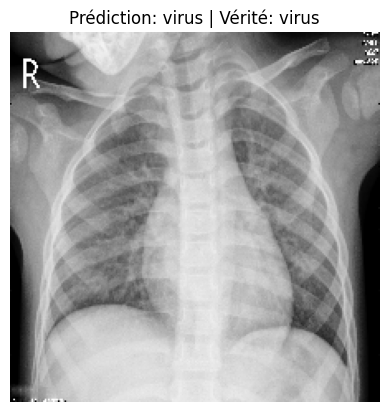

Image sélectionnée: /kaggle/working/split_data/test/virus/526258730.jpeg
Classe prédite: virus
Classe réelle: virus


In [11]:
import os
import random
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import img_to_array

# Charger le modèle entraîné
model = load_model('best_model.keras')

# Répertoire contenant les images de test
test_dir = '/kaggle/working/split_data/test'

# Liste des classes
class_names = ['covid', 'normal', 'virus']

# Sélectionner une image aléatoire du répertoire de test
def random_image_from_directory(directory):
    # Choisir une classe au hasard
    class_name = random.choice(os.listdir(directory))
    class_path = os.path.join(directory, class_name)
    
    # Choisir une image au hasard dans cette classe
    image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, image_name)
    
    return image_path, class_name

# Charger et préparer l'image
def prepare_image(image_path, target_size=(224, 224)):
    img = image.load_img(image_path, target_size=target_size, color_mode='grayscale')
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Ajouter une dimension pour le batch
    img_array /= 255.0  # Normaliser l'image
    return img_array

# Sélectionner une image aléatoire et la prédire
image_path, true_class = random_image_from_directory(test_dir)
img_array = prepare_image(image_path)

# Prédire l'image
predictions = model.predict(img_array)
predicted_class_index = np.argmax(predictions, axis=1)[0]
predicted_class = class_names[predicted_class_index]

# Afficher l'image et la prédiction
img = image.load_img(image_path, target_size=(224, 224), color_mode='grayscale')
plt.imshow(img, cmap='gray')
plt.title(f"Prédiction: {predicted_class} | Vérité: {true_class}")
plt.axis('off')
plt.show()

print(f"Image sélectionnée: {image_path}")
print(f"Classe prédite: {predicted_class}")
print(f"Classe réelle: {true_class}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


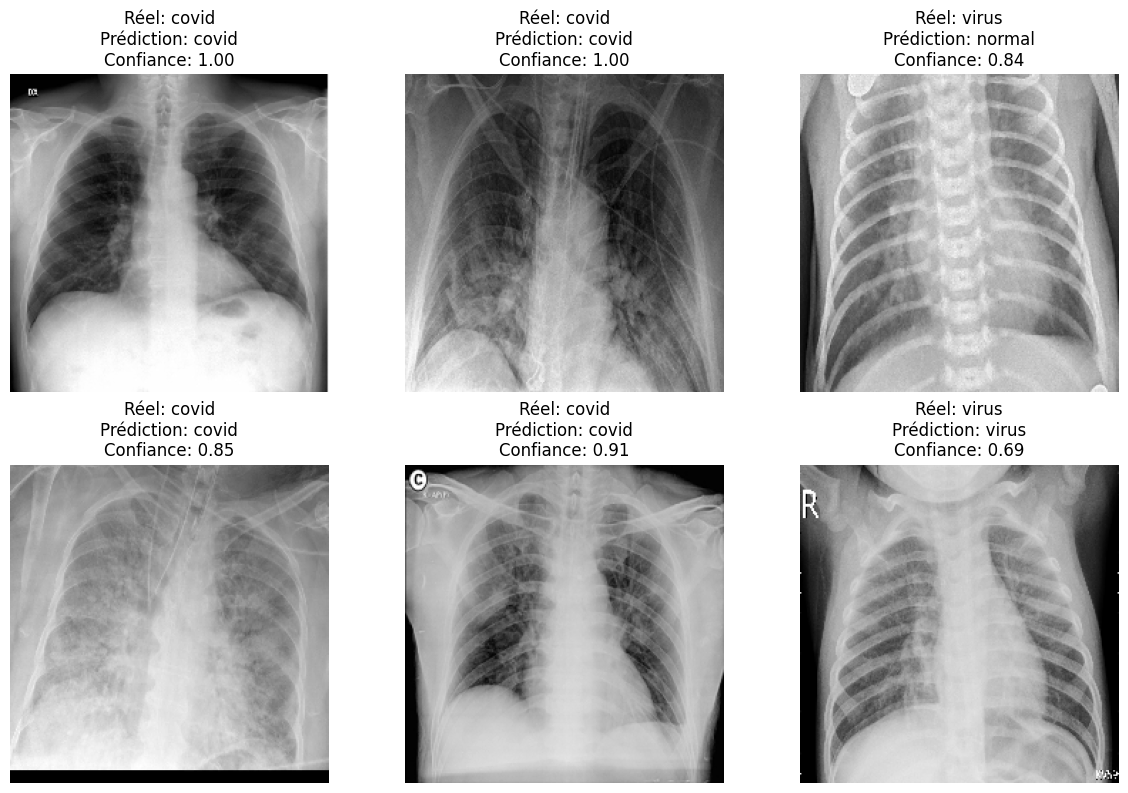

In [14]:
import os
import random
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import img_to_array

# Charger le modèle entraîné
model = load_model('best_model.keras')

# Répertoire contenant les images de test
test_dir = '/kaggle/working/split_data/test'

# Liste des classes
class_names = ['covid', 'normal', 'virus']

# Sélectionner une image aléatoire du répertoire de test
def random_image_from_directory(directory):
    # Choisir une classe au hasard
    class_name = random.choice(os.listdir(directory))
    class_path = os.path.join(directory, class_name)
    
    # Choisir une image au hasard dans cette classe
    image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, image_name)
    
    return image_path, class_name

# Charger et préparer l'image
def prepare_image(image_path, target_size=(224, 224)):
    img = image.load_img(image_path, target_size=target_size, color_mode='grayscale')
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Ajouter une dimension pour le batch
    img_array /= 255.0  # Normaliser l'image
    return img_array

# Prédiction sur plusieurs images
def predict_random_images(num_images=6):
    fig, axs = plt.subplots(2, 3, figsize=(12, 8))  # Créer un subplot pour afficher les images
    axs = axs.ravel()

    for i in range(num_images):
        # Sélectionner une image aléatoire
        image_path, true_class = random_image_from_directory(test_dir)
        
        # Préparer l'image pour la prédiction
        img_array = prepare_image(image_path)
        
        # Prédire l'image
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        predicted_class = class_names[predicted_class_index]
        confidence = np.max(predictions)  # La valeur de confiance (probabilité maximale)

        # Afficher l'image et la prédiction avec la confiance et la classe réelle
        img = image.load_img(image_path, target_size=(224, 224), color_mode='grayscale')
        axs[i].imshow(img, cmap='gray')
        axs[i].set_title(f"Réel: {true_class}\nPrédiction: {predicted_class}\nConfiance: {confidence:.2f}")
        axs[i].axis('off')  # Enlever les axes

    plt.tight_layout()
    plt.show()

# Appeler la fonction pour prédire sur 6 images aléatoires
predict_random_images(num_images=6)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


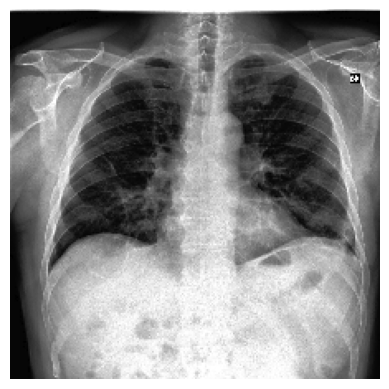

Classe prédite: covid
Confiance: 99.99%


In [19]:
#Prediction d'une image dans une autre data

import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Chemin de l'image à prédire
image_path = '/kaggle/input/covid19-image-dataset/Covid19-dataset/test/Covid/0100.jpeg'

# Charger le modèle sauvegardé
model = tf.keras.models.load_model('best_model.keras')

# Charger l'image et la prétraiter
img = image.load_img(image_path, target_size=(224, 224), color_mode='grayscale')  # Adapter la taille à celle utilisée pendant l'entraînement
img_array = image.img_to_array(img)  # Convertir l'image en array
img_array = np.expand_dims(img_array, axis=0)  # Ajouter une dimension batch
img_array = img_array / 255.0  # Normaliser l'image (comme pendant l'entraînement)

# Prédiction
predictions = model.predict(img_array)

# Afficher l'image
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

# Afficher la classe prédite et la confiance
class_labels = ['covid', 'normal', 'virus']
predicted_class = class_labels[np.argmax(predictions)]  # Trouver la classe prédite
confidence = np.max(predictions)  # La probabilité la plus élevée

print(f'Classe prédite: {predicted_class}')
print(f'Confiance: {confidence * 100:.2f}%')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


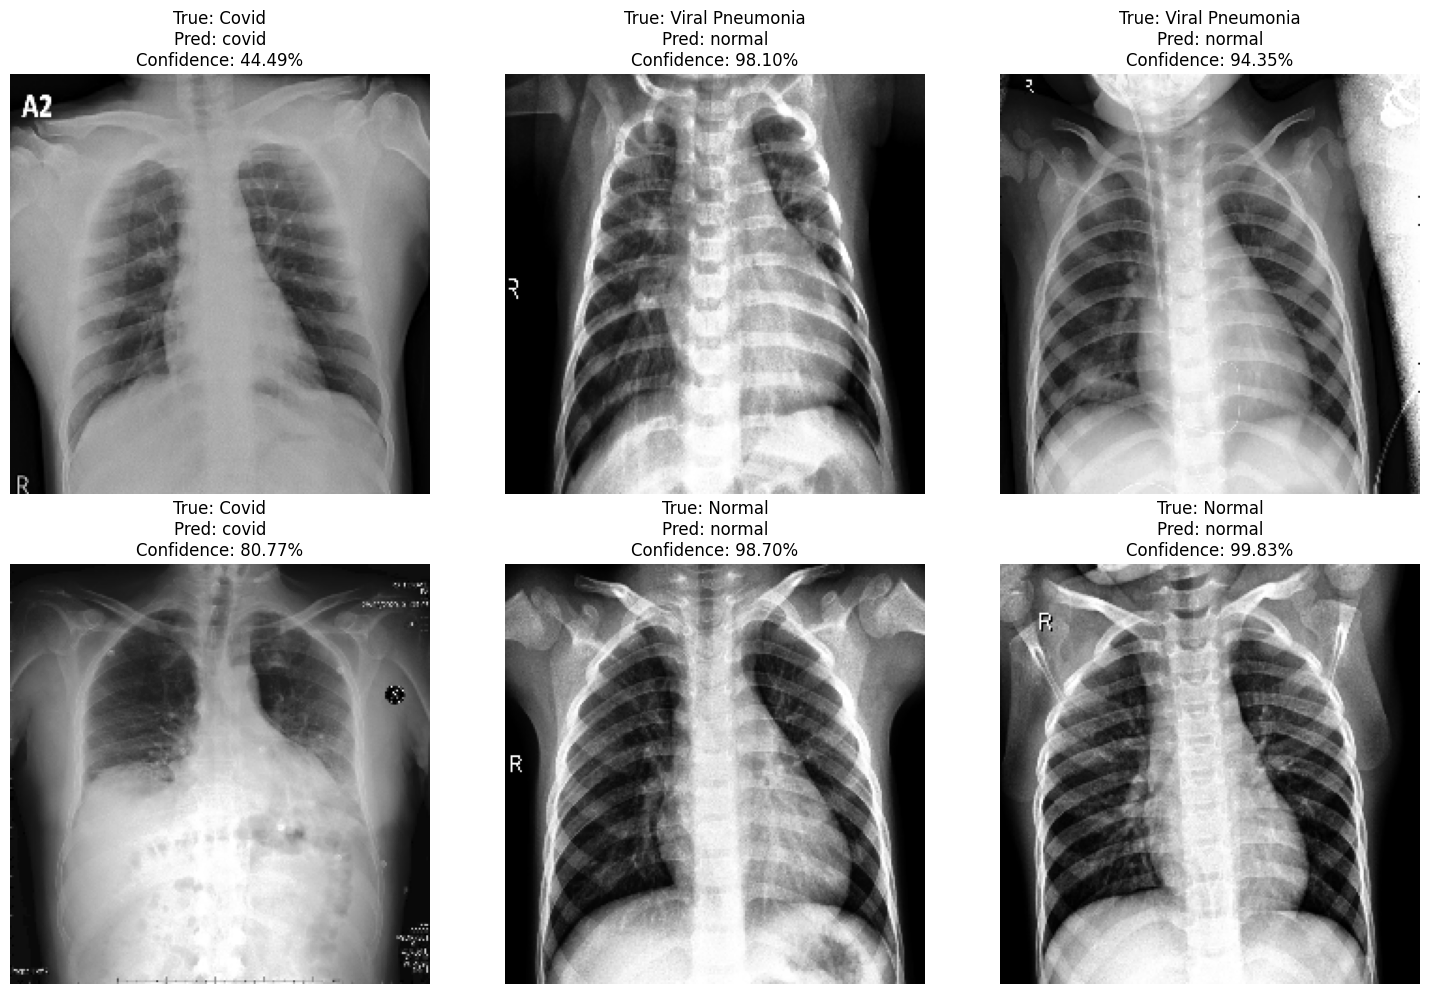

In [21]:
# Prédiction de 06 images sur une autre data incluant la classe pneunomie

import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import os
import random
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Chemin du dossier test
test_dir = '/kaggle/input/covid19-image-dataset/Covid19-dataset/test'

# Charger le modèle sauvegardé
model = tf.keras.models.load_model('best_model.keras')

# Fonction pour charger et prétraiter l'image
def prepare_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224), color_mode='grayscale')  # Adapter la taille à celle utilisée pendant l'entraînement
    img_array = image.img_to_array(img)  # Convertir l'image en array
    img_array = np.expand_dims(img_array, axis=0)  # Ajouter une dimension batch
    img_array = img_array / 255.0  # Normaliser l'image (comme pendant l'entraînement)
    return img_array, img

# Sélectionner 6 images aléatoires du dossier test
all_images = []
true_classes = []  # Liste pour stocker les classes réelles
for cls in os.listdir(test_dir):
    cls_dir = os.path.join(test_dir, cls)
    if os.path.isdir(cls_dir):
        images = [os.path.join(cls_dir, img) for img in os.listdir(cls_dir)]
        all_images.extend(images)
        true_classes.extend([cls] * len(images))  # Ajouter la classe réelle

# Tirer 6 images aléatoires
random_indices = random.sample(range(len(all_images)), 6)
random_images = [all_images[i] for i in random_indices]
random_true_classes = [true_classes[i] for i in random_indices]

# Afficher les images avec prédictions
class_labels = ['covid', 'normal', 'virus']

# Créer une figure avec 2 lignes et 3 colonnes
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Placer les images et les prédictions
for i, ax in enumerate(axes.flat):
    img_path = random_images[i]
    true_class = random_true_classes[i]
    
    # Préparer l'image
    img_array, img = prepare_image(img_path)

    # Prédiction
    predictions = model.predict(img_array)
    
    # Classe prédite et confiance
    predicted_class = class_labels[np.argmax(predictions)]  # Trouver la classe prédite
    confidence = np.max(predictions)  # La probabilité la plus élevée
    
    # Affichage de l'image et des détails
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    ax.set_title(f"True: {true_class}\nPred: {predicted_class}\nConfidence: {confidence*100:.2f}%")

# Afficher la figure
plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


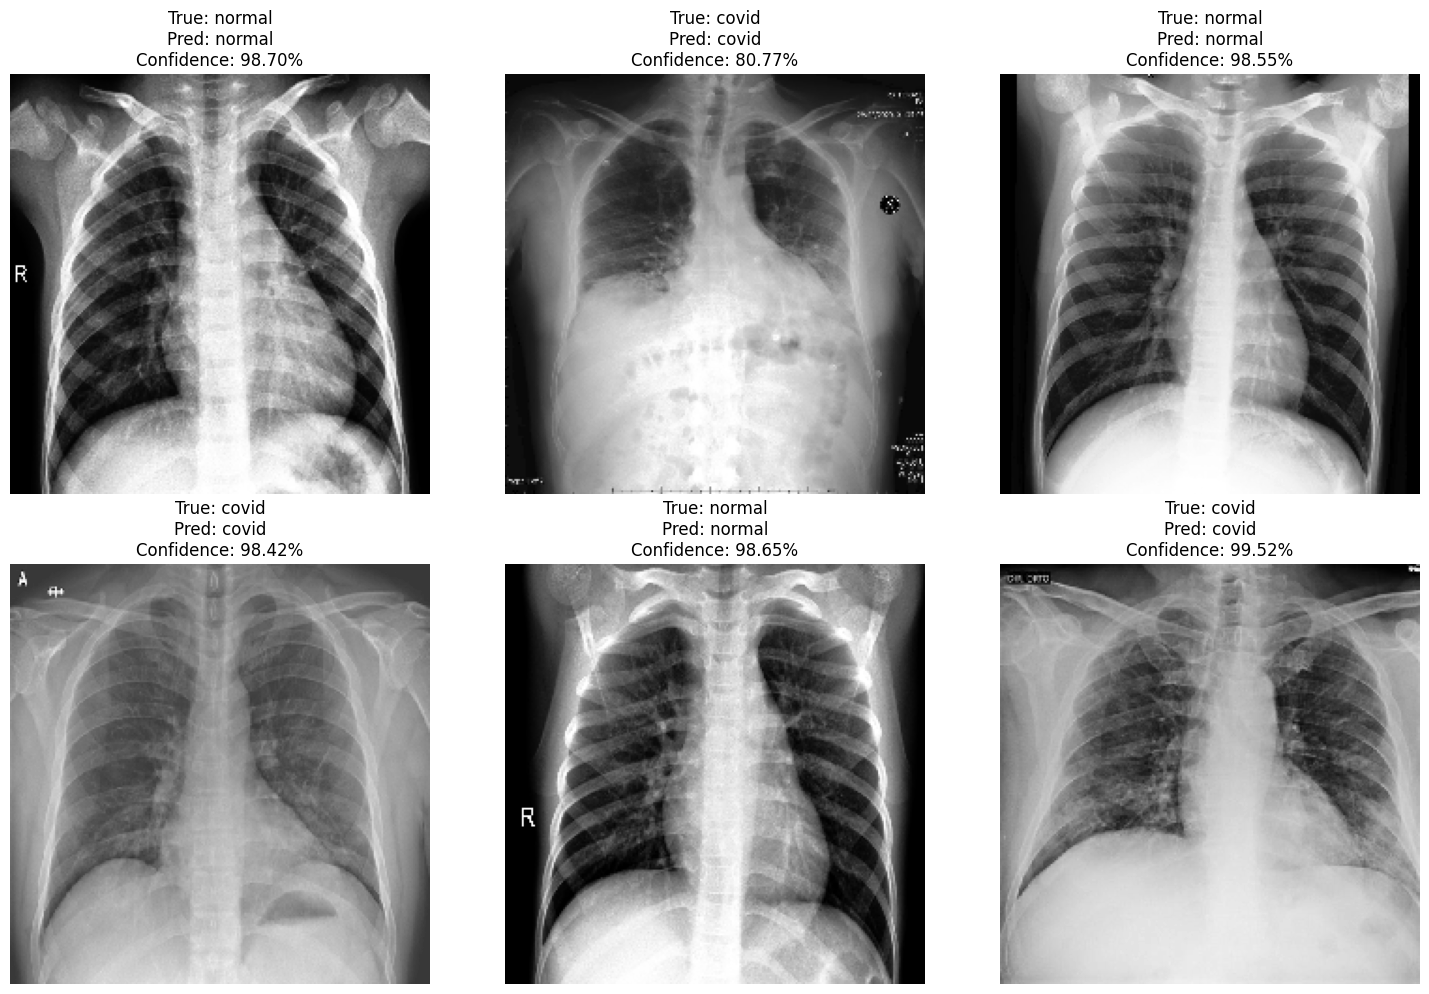

In [24]:
# Prédiction de 06 images dans une autre data excluant la classe pneunomie

import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import os
import random
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Chemins des sous-dossiers "Covid" et "Normal"
covid_dir = '/kaggle/input/covid19-image-dataset/Covid19-dataset/test/Covid'
normal_dir = '/kaggle/input/covid19-image-dataset/Covid19-dataset/test/Normal'

# Charger le modèle sauvegardé
model = tf.keras.models.load_model('best_model.keras')

# Fonction pour charger et prétraiter l'image
def prepare_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224), color_mode='grayscale')  # Adapter la taille à celle utilisée pendant l'entraînement
    img_array = image.img_to_array(img)  # Convertir l'image en array
    img_array = np.expand_dims(img_array, axis=0)  # Ajouter une dimension batch
    img_array = img_array / 255.0  # Normaliser l'image (comme pendant l'entraînement)
    return img_array, img

# Charger les images des sous-dossiers "Covid" et "Normal"
all_images = []
true_classes = []  # Liste pour stocker les classes réelles

# Charger les images dans le dossier "Covid"
covid_images = [os.path.join(covid_dir, img) for img in os.listdir(covid_dir) if img.endswith(('.jpg', '.jpeg', '.png'))]
all_images.extend(covid_images)
true_classes.extend(['covid'] * len(covid_images))  # Ajouter la classe "covid" pour ces images

# Charger les images dans le dossier "Normal"
normal_images = [os.path.join(normal_dir, img) for img in os.listdir(normal_dir) if img.endswith(('.jpg', '.jpeg', '.png'))]
all_images.extend(normal_images)
true_classes.extend(['normal'] * len(normal_images))  # Ajouter la classe "normal" pour ces images

# Vérification du nombre d'images disponibles
if len(all_images) < 6:
    raise ValueError(f"Il n'y a pas assez d'images disponibles dans les sous-dossiers 'Covid' et 'Normal'. Il y en a seulement {len(all_images)}.")

# Tirer 6 images aléatoires
random_indices = random.sample(range(len(all_images)), 6)
random_images = [all_images[i] for i in random_indices]
random_true_classes = [true_classes[i] for i in random_indices]

# Afficher les images avec prédictions
class_labels = ['covid', 'normal']

# Créer une figure avec 2 lignes et 3 colonnes
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Placer les images et les prédictions
for i, ax in enumerate(axes.flat):
    img_path = random_images[i]
    true_class = random_true_classes[i]
    
    # Préparer l'image
    img_array, img = prepare_image(img_path)

    # Prédiction
    predictions = model.predict(img_array)
    
    # Classe prédite et confiance
    predicted_class = class_labels[np.argmax(predictions)]  # Trouver la classe prédite
    confidence = np.max(predictions)  # La probabilité la plus élevée
    
    # Affichage de l'image et des détails
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    ax.set_title(f"True: {true_class}\nPred: {predicted_class}\nConfidence: {confidence*100:.2f}%")

# Afficher la figure
plt.tight_layout()
plt.show()


Found 122 images belonging to 3 classes.
 1/16 ━━━━━━━━━━━━━━━━━━━━ 3s 214ms/step

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step


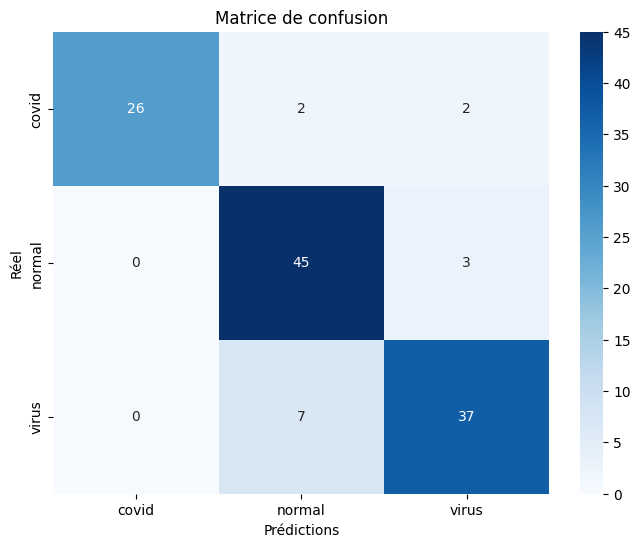

Classe: covid
Vrais Positifs (TP): 26
Faux Positifs (FP): 0
Faux Négatifs (FN): 4
Vrais Négatifs (TN): 92
------------------------------
Classe: normal
Vrais Positifs (TP): 45
Faux Positifs (FP): 9
Faux Négatifs (FN): 3
Vrais Négatifs (TN): 65
------------------------------
Classe: virus
Vrais Positifs (TP): 37
Faux Positifs (FP): 5
Faux Négatifs (FN): 7
Vrais Négatifs (TN): 73
------------------------------

Rapport de classification :
              precision    recall  f1-score   support

       covid       1.00      0.87      0.93        30
      normal       0.83      0.94      0.88        48
       virus       0.88      0.84      0.86        44

    accuracy                           0.89       122
   macro avg       0.90      0.88      0.89       122
weighted avg       0.89      0.89      0.89       122



In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Charger le modèle entraîné
model = load_model('best_model.keras')

# Répertoire contenant les données de test
test_dir = '/kaggle/working/split_data/test'

# Paramètres
IMAGE_SIZE = 224
BATCH_SIZE = 8

# Data generator pour les données de test
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical',
    shuffle=False  # Pas de shuffle pour la matrice de confusion
)

# Prédire sur l'ensemble des images de test
predictions = model.predict(test_generator, verbose=1)

# Obtenir les classes prédites
predicted_classes = np.argmax(predictions, axis=1)

# Obtenir les classes réelles
true_classes = test_generator.classes

# Calcul de la matrice de confusion
cm = confusion_matrix(true_classes, predicted_classes)

# Affichage de la matrice de confusion
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.title('Matrice de confusion')
plt.xlabel('Prédictions')
plt.ylabel('Réel')
plt.show()

# Calcul des métriques (vrais positifs, faux positifs, etc.) pour chaque classe
class_names = list(test_generator.class_indices.keys())
for i, class_name in enumerate(class_names):
    TP = cm[i, i]  # Vrais positifs pour la classe i
    FP = cm[:, i].sum() - TP  # Faux positifs pour la classe i
    FN = cm[i, :].sum() - TP  # Faux négatifs pour la classe i
    TN = cm.sum() - (TP + FP + FN)  # Vrais négatifs pour la classe i
    
    print(f"Classe: {class_name}")
    print(f"Vrais Positifs (TP): {TP}")
    print(f"Faux Positifs (FP): {FP}")
    print(f"Faux Négatifs (FN): {FN}")
    print(f"Vrais Négatifs (TN): {TN}")
    print("-" * 30)

# Affichage du rapport de classification (precision, recall, f1-score)
print("\nRapport de classification :")
print(classification_report(true_classes, predicted_classes, target_names=test_generator.class_indices.keys()))
